### Spatial and frequency views
The three code cells below produce two images: a spatial view of one image and a frequency view calculated from the dataset's mean image.

In [19]:
'''
Import libraries and load the dataset.
'''

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from scipy.ndimage import sobel

ROOT = Path("Bird Speciees Dataset")  
IMAGE_SIZE = (224,224)
EXTS = {".jpg", ".jpeg", ".png"}   # Allowed image file extensions
paths = sorted(
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in EXTS
)

if not paths:
    raise FileNotFoundError(f"No images found in {ROOT.resolve()}")

print(f"{len(paths)} images")

811 images


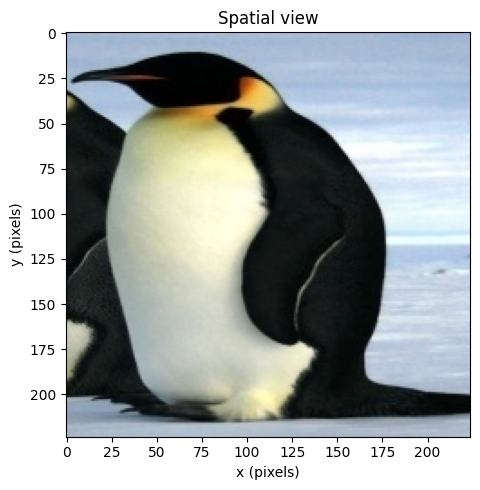

In [20]:
used_image = paths[550]  # Change this index to use a different image
arr = np.asarray(Image.open(used_image).convert("RGB"))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(arr)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Spatial view")
plt.tight_layout()
plt.show()

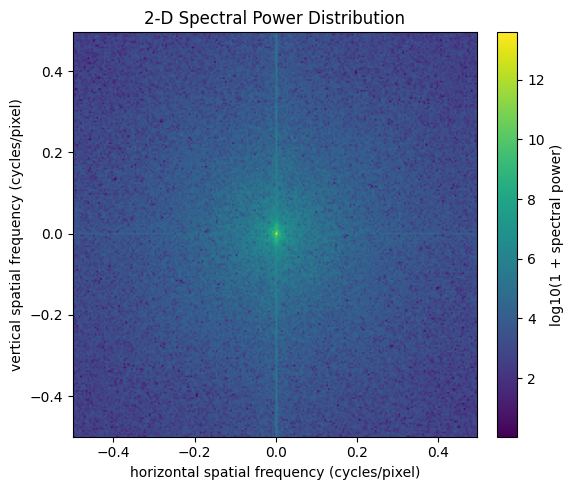

In [21]:
# Mean image across the dataset
mean_img = np.zeros((*IMAGE_SIZE, 3), dtype=np.float64)
for p in paths:
    mean_img += np.asarray(Image.open(p).convert("RGB"), dtype=np.float64)
mean_img /= len(paths)
gray = mean_img.mean(axis=2)

# 2-D Fourier transform and spectral power distribution
F = np.fft.fftshift(np.fft.fft2(gray))
power = np.abs(F) ** 2
power_log = np.log10(1 + power)

# Spatial-frequency coordinates in cycles per pixel
height, width = gray.shape
u = np.fft.fftshift(np.fft.fftfreq(width))
v = np.fft.fftshift(np.fft.fftfreq(height))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    power_log,
    extent=[u[0], u[-1], v[0], v[-1]],
    origin="lower",
    cmap="viridis",
    aspect="equal",
)
ax.set_xlabel("horizontal spatial frequency (cycles/pixel)")
ax.set_ylabel("vertical spatial frequency (cycles/pixel)")
ax.set_title("2-D Spectral Power Distribution")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log10(1 + spectral power)")
plt.tight_layout()
plt.show()

Copied from p1.md
### Transformation experiment
For this experiment, the transformation used is Sobel edge detection.

**Prediction:** Sobel edge detection will produce stronger and more accurate responses at high-contrast features such as the bird's beak and eye, and weaker responses across the body where brightness changes are more gradual. The strength of the bird's outline will also depend on the contrast between the bird and its background. For example, a penguin's white feathers will produce a weaker outline against a snowy background.

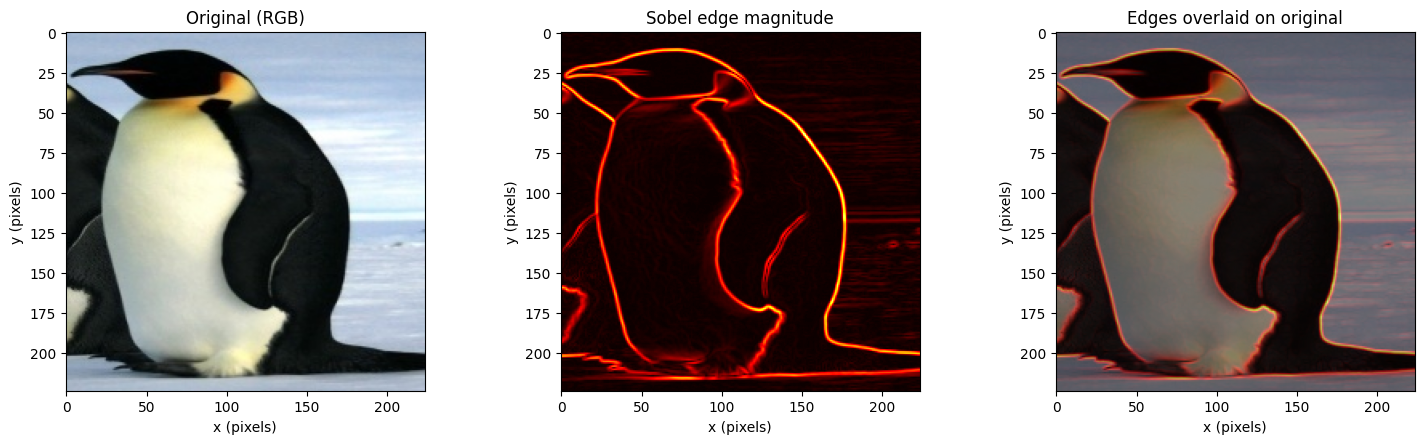

In [22]:
# One image: load it in RGB and grayscale

rgb = np.asarray(Image.open(used_image).convert("RGB"))
gray = np.asarray(Image.open(used_image).convert("L"), dtype=np.float64)

# Sobel edges
gx = sobel(gray, axis=1)
gy = sobel(gray, axis=0)
mag = np.hypot(gx, gy)

# Show the original image, the edges, and the overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(rgb)
axes[0].set_title("Original (RGB)")
axes[0].set_xlabel("x (pixels)"); axes[0].set_ylabel("y (pixels)")

axes[1].imshow(mag, cmap="hot")
axes[1].set_title("Sobel edge magnitude")
axes[1].set_xlabel("x (pixels)"); axes[1].set_ylabel("y (pixels)")

axes[2].imshow(rgb)
axes[2].imshow(mag, cmap="hot", alpha=0.5)
axes[2].set_title("Edges overlaid on original")
axes[2].set_xlabel("x (pixels)"); axes[2].set_ylabel("y (pixels)")

plt.tight_layout()
plt.show()

### Sobel findings
Inspecting dozens of images from this experiment, the initial predictions were mostly correct. The beak, eye, feather boundaries and the bird outline give the strongest responses, while smooth body regions give weak responses. The outline becomes weak where the bird and background have similar brightness, for example the Emperor Penguin's white front against snow.

### How much signal can be removed before the bird can no longer be identified?

To determine this, the average image for each bird species will first be calculated.

AMERICAN GOLDFINCH: strongest non-zero spatial frequency = 0.0022 cycles/pixel


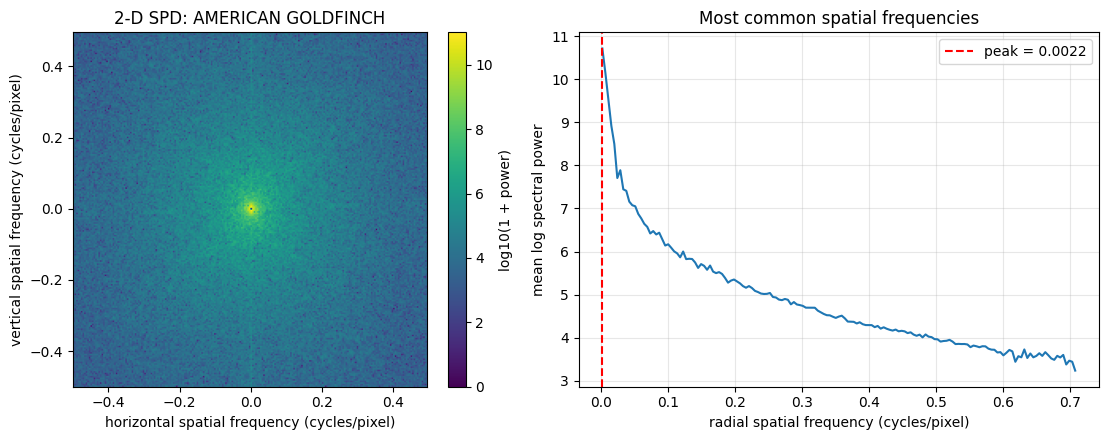

BARN OWL: strongest non-zero spatial frequency = 0.0022 cycles/pixel


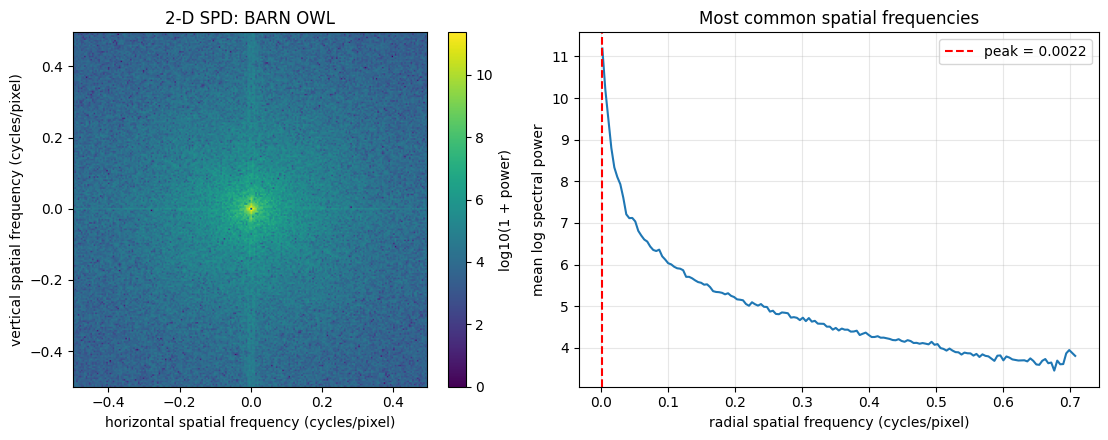

CARMINE BEE-EATER: strongest non-zero spatial frequency = 0.0022 cycles/pixel


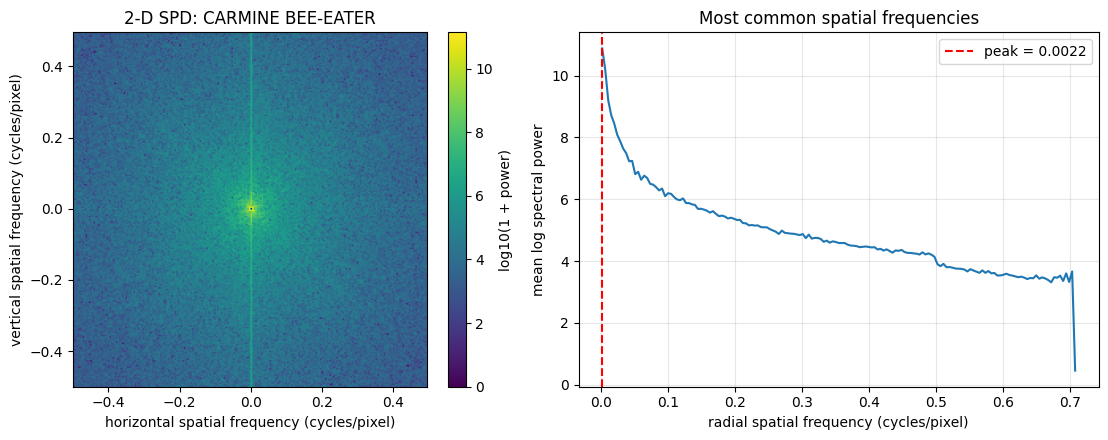

DOWNY WOODPECKER: strongest non-zero spatial frequency = 0.0022 cycles/pixel


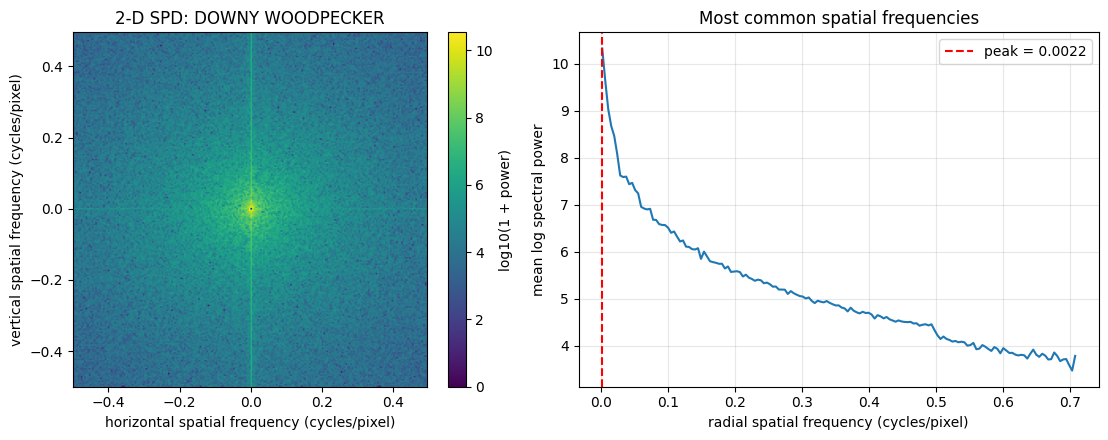

EMPEROR PENGUIN: strongest non-zero spatial frequency = 0.0022 cycles/pixel


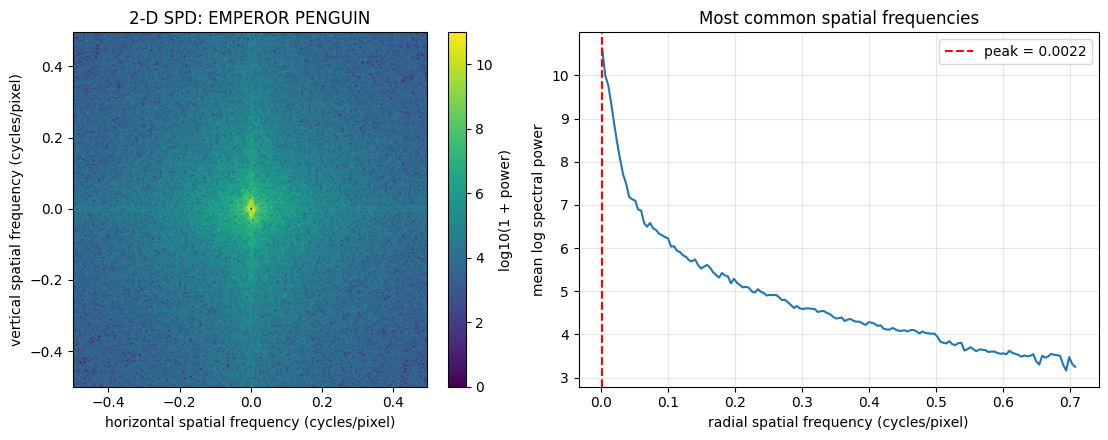

FLAMINGO: strongest non-zero spatial frequency = 0.0022 cycles/pixel


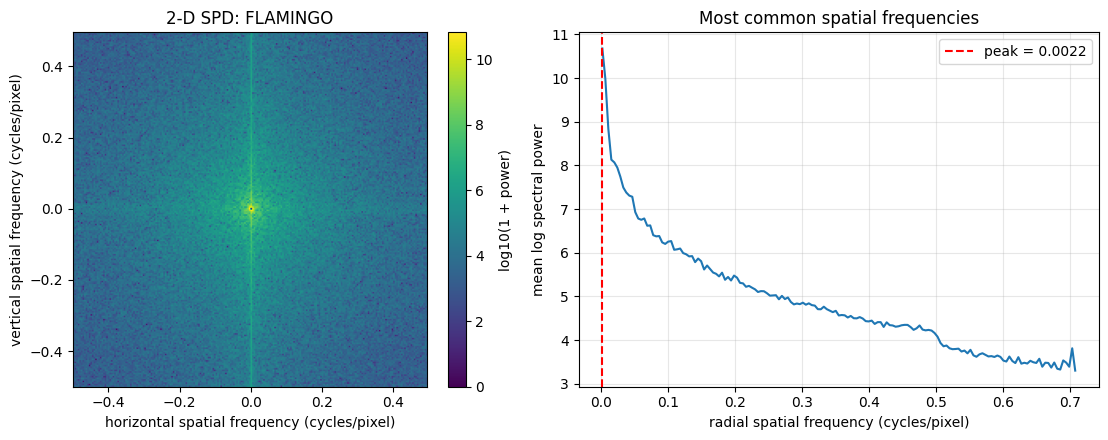

In [23]:
# Convert images to grayscale and calculate one average image per species.
species = ["AMERICAN GOLDFINCH", "BARN OWL", "CARMINE BEE-EATER", "DOWNY WOODPECKER", "EMPEROR PENGUIN", "FLAMINGO"]

species_means = {bird: np.zeros(IMAGE_SIZE, dtype=np.float64) for bird in species}
species_counts = {bird: 0 for bird in species}

for p in paths:
    bird = p.parent.name
    if bird in species:
        species_means[bird] += np.asarray(Image.open(p).convert("L"), dtype=np.float64)
        species_counts[bird] += 1

species_means = {
    bird: species_means[bird] / species_counts[bird]
    for bird in species
}

# Average 2-D power over circular frequency bands.
def radial_power_spectrum(image):
    image = image - image.mean()  # Remove the dominant zero-frequency brightness component.
    F = np.fft.fftshift(np.fft.fft2(image))
    power = np.abs(F) ** 2

    height, width = image.shape
    u = np.fft.fftshift(np.fft.fftfreq(width))
    v = np.fft.fftshift(np.fft.fftfreq(height))
    uu, vv = np.meshgrid(u, v)
    radius = np.sqrt(uu**2 + vv**2)

    frequency_step = min(abs(u[1] - u[0]), abs(v[1] - v[0]))
    bin_edges = np.arange(0, radius.max() + frequency_step, frequency_step)
    bin_numbers = np.digitize(radius.ravel(), bin_edges)
    frequencies = (bin_edges[:-1] + bin_edges[1:]) / 2
    radial_power = np.array([
        power.ravel()[bin_numbers == i].mean()
        if np.any(bin_numbers == i) else np.nan
        for i in range(1, len(bin_edges))
    ])

    return F, power, u, v, frequencies, radial_power

for bird in species:
    F, power, u, v, frequencies, radial_power = radial_power_spectrum(species_means[bird])
    power_log = np.log10(1 + power)

    # Ignore the first radial bin when finding the strongest non-zero frequency.
    valid = np.isfinite(radial_power) & (frequencies > 0)
    peak_frequency = frequencies[valid][np.argmax(radial_power[valid])]
    print(f"{bird}: strongest non-zero spatial frequency = {peak_frequency:.4f} cycles/pixel")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    im = axes[0].imshow(
        power_log,
        extent=[u[0], u[-1], v[0], v[-1]],
        origin="lower",
        cmap="viridis",
        aspect="equal",
    )
    axes[0].set_xlabel("horizontal spatial frequency (cycles/pixel)")
    axes[0].set_ylabel("vertical spatial frequency (cycles/pixel)")
    axes[0].set_title(f"2-D SPD: {bird}")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="log10(1 + power)")

    axes[1].plot(frequencies[valid], np.log10(1 + radial_power[valid]))
    axes[1].axvline(peak_frequency, color="red", linestyle="--", label=f"peak = {peak_frequency:.4f}")
    axes[1].set_xlabel("radial spatial frequency (cycles/pixel)")
    axes[1].set_ylabel("mean log spectral power")
    axes[1].set_title("Most common spatial frequencies")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Fourier-feature test accuracy: 46.8%
Six-class chance accuracy: 16.7%

                    precision    recall  f1-score   support

AMERICAN GOLDFINCH       0.41      0.19      0.26        36
          BARN OWL       0.38      0.31      0.34        32
 CARMINE BEE-EATER       0.45      0.45      0.45        33
  DOWNY WOODPECKER       0.61      0.79      0.69        34
   EMPEROR PENGUIN       0.49      0.63      0.55        35
          FLAMINGO       0.37      0.42      0.39        33

          accuracy                           0.47       203
         macro avg       0.45      0.47      0.45       203
      weighted avg       0.45      0.47      0.45       203



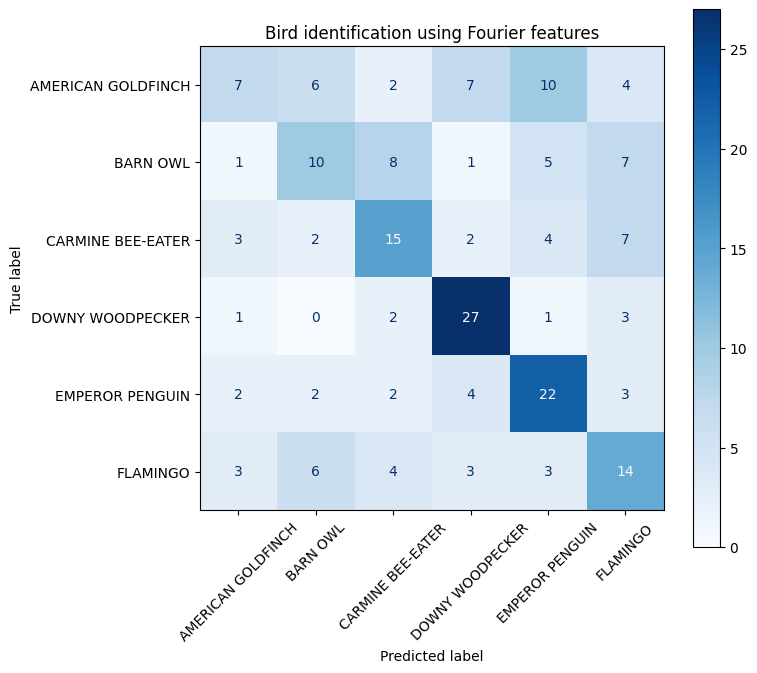

In [24]:
# Test whether radial Fourier power can distinguish individual bird images.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

feature_rows = []
labels = []

for p in paths:
    bird = p.parent.name
    if bird not in species:
        continue

    image = np.asarray(Image.open(p).convert("L"), dtype=np.float64)
    _, _, _, _, frequencies, radial_power = radial_power_spectrum(image)
    feature_rows.append(np.log1p(np.nan_to_num(radial_power, nan=0.0)))
    labels.append(bird)

X = np.asarray(feature_rows)
y = np.asarray(labels)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
chance_accuracy = 1 / len(species)
print(f"Fourier-feature test accuracy: {accuracy:.1%}")
print(f"Six-class chance accuracy: {chance_accuracy:.1%}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=species,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Bird identification using Fourier features")
plt.tight_layout()
plt.show()

### Resampling and quantisation experiment: finding artefacts and limitations
For this task, we use quantisation to examine how gradually reducing the number of allowed intensity values affects the images.

***Prediction:*** Because the birds have features with sudden transitions rather than gradual ones, we predict that the birds will not be strongly affected by quantisation until the bit depth is fairly low. Meanwhile, the backgrounds in many images contain gradual colour changes and will therefore be heavily affected by artefacts or may even be destroyed by quantisation.

 bits  levels  unique vals   mean error
    8     256          256         0.00
    6      64           64         1.00
    4      16           16         4.16
    3       8            8         9.60
    2       4            4        19.66
    1       2            2        42.55


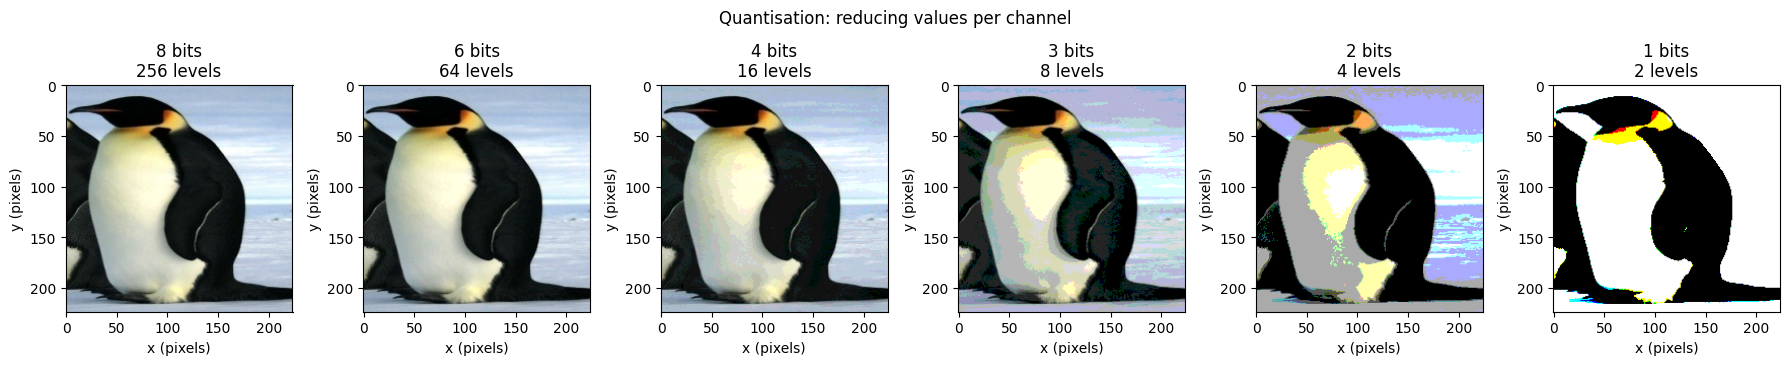

In [25]:
img = np.asarray(Image.open(used_image).convert("RGB"), dtype=np.uint8)

def quantise(arr, bits):
    levels = 2**bits
    step = 255 / (levels - 1)
    q = np.round(arr / step) * step
    return np.clip(q, 0, 255).astype(np.uint8)

bit_levels = [8, 6, 4, 3, 2, 1]

# Numeric summary
print(f"{'bits':>5s} {'levels':>7s} {'unique vals':>12s} {'mean error':>12s}")
for b in bit_levels:
    q = quantise(img, b)
    unique = len(np.unique(q))
    err = np.abs(img.astype(int) - q.astype(int)).mean()
    print(f"{b:>5d} {2**b:>7d} {unique:>12d} {err:>12.2f}")

# Visual grid
fig, axes = plt.subplots(1, len(bit_levels), figsize=(3*len(bit_levels), 3.6))
for ax, b in zip(axes, bit_levels):
    ax.imshow(quantise(img, b))
    ax.set_title(f"{b} bits\n{2**b} levels")
    ax.set_xlabel("x (pixels)"); ax.set_ylabel("y (pixels)")
plt.suptitle("Quantisation: reducing values per channel")
plt.tight_layout()
plt.show()

### Quantisation findings
The quantisation results generally correspond to the predictions. In many images, the background produces artefacts at higher bit depths than the bird does. There are exceptions, such as the Downy Woodpecker, whose feathers contain more gradual colour changes.
With an interesting finding being that birds generally survive quantisation pretty well, which for this dataset is important since it is the most important feature of the images. 

### Image loader
The loader code is provided below.

`list_images` lists all images in the dataset while keeping them in the same sorted order each time, making the loader reproducible.

`load_image` loads an image and converts it to RGB using `uint8`, ensuring a consistent representation.

`load_baseline` loads the full dataset and can be used as a baseline for P2.

In [26]:
def list_images(root=ROOT):
    """Return all supported image paths in deterministic sorted order."""
    return sorted(
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in EXTS
    )

def load_image(path):
    """Load an image as RGB uint8 while preserving its native resolution."""
    try:
        with Image.open(path) as im:
            return np.asarray(im.convert("RGB"), dtype=np.uint8)
    except Exception as e:
        raise RuntimeError(f"Failed to load image: {path}") from e

def load_baseline(root=ROOT):
    """Load the entire dataset as a single uint8 array of shape (N, H, W, 3)."""
    paths = list_images(root)
    if not paths:
        raise RuntimeError(f"No images found under {root}")
    arrays = [load_image(p) for p in paths]
    return paths, np.stack(arrays)